<a href="https://colab.research.google.com/github/ZeninKris/zmm-movilidad-predictiva/blob/main/notebooks/02_Feature_Engineering_Tiempo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 02 — Feature Engineering: Esqueleto Temporal y Eventos

## Objetivo
Construir el esqueleto temporal del proyecto: una fila por cada hora
del período 2023-2026, con variables que capturan los ciclos de la
ciudad y el impacto de eventos masivos.

## Variables generadas
- `es_fin_de_semana` — binario: sábado o domingo
- `es_hora_pico` — binario: horas de alta congestión vehicular
- `tipo_dia` — categórica: perfil del día según patrón de movilidad
- `impacto_evento_activo` — señal anticipada de eventos masivos

## Decisión técnica: horas pico
El EDA de OCISEVI (Notebook 04) reveló tres picos horarios reales:
- 7-9h: entrada turno matutino industrial
- 14-15h: salida turno matutino / entrada turno vespertino simultáneos
- 17-20h: salida turno vespertino / hora pico tradicional
El pico de 14-15h no estaba en la versión original y se incorpora aquí.

## Decisión técnica: tipo_dia
El heatmap hora×día reveló tres perfiles distintos de movilidad:
- laboral_industrial: lunes a viernes (perfil de parques industriales)
- laboral_mixto: sábado (medio turno, pico desplazado a 13-15h)
- fin_de_semana: domingo (perfil recreativo/familiar, tarde-noche)
La variable `dia_semana` sola no captura esta distinción.



In [1]:
import pandas as pd
import numpy as np

# ============================================================
# CELDA 1 — Construcción del esqueleto temporal 2023-2026
# ============================================================

# --- 1.1 Generar una fila por cada hora del período ---
rango_fechas = pd.date_range(
    start='2023-01-01 00:00:00',
    end='2026-12-31 23:00:00',
    freq='h'
)
df_tiempo = pd.DataFrame({'fecha_hora': rango_fechas})

# --- 1.2 Variables temporales básicas ---
df_tiempo['año']          = df_tiempo['fecha_hora'].dt.year
df_tiempo['mes']          = df_tiempo['fecha_hora'].dt.month
df_tiempo['dia_semana']   = df_tiempo['fecha_hora'].dt.dayofweek  # Lun=0, Dom=6
df_tiempo['hora_del_dia'] = df_tiempo['fecha_hora'].dt.hour
df_tiempo['es_fin_de_semana'] = (df_tiempo['dia_semana'] >= 5).astype(int)

# --- 1.3 Intensidad de hora pico — variable ordinal 0/1/2 ---
# Justificación: el EDA OCISEVI reveló gradiente real entre horas.
# Las 8h y 14-15h concentran significativamente más siniestros
# que las horas adyacentes — no todas las horas pico son iguales.
# Referencia: Feature Engineering for ML (O'Reilly) — cap. variables ordinales
#
# Nivel 0 → hora normal        (línea base, sin presión vial)
# Nivel 1 → hora pico moderada (rampas de subida/bajada del pico)
# Nivel 2 → hora pico intensa  (centro del pico, máxima concentración)

def clasificar_hora_pico(h):
    if h in [8, 14, 15, 18, 19]:    # centros de pico confirmados en EDA
        return 2
    elif h in [7, 9, 17, 20]:        # bordes del pico, transición
        return 1
    else:
        return 0

df_tiempo['intensidad_hora_pico'] = df_tiempo['hora_del_dia'].apply(clasificar_hora_pico)

# --- 1.4 Tipo de día — tres perfiles de movilidad distintos ---
# Descubierto en heatmap hora×día del EDA OCISEVI (Notebook 04)
def clasificar_tipo_dia(row):
    if row['dia_semana'] == 6:    # domingo
        return 'fin_de_semana'
    elif row['dia_semana'] == 5:  # sábado
        return 'laboral_mixto'
    else:                          # lunes a viernes
        return 'laboral_industrial'

df_tiempo['tipo_dia'] = df_tiempo.apply(clasificar_tipo_dia, axis=1)

# --- 1.5 Verificación ---
# --- 1.5 Verificación ---
print(f"Esqueleto creado: {df_tiempo.shape[0]:,} horas en total")
print(f"\nPrimeras filas:")
print(df_tiempo.head())

print(f"\nDistribución de tipo_dia:")
print(df_tiempo['tipo_dia'].value_counts())

print(f"\nDistribución de intensidad_hora_pico:")
dist = df_tiempo['intensidad_hora_pico'].value_counts().sort_index()
for nivel, count in dist.items():
    pct = count / len(df_tiempo) * 100
    barra = '█' * int(pct / 1)
    print(f"  Nivel {nivel}: {count:>6,} horas ({pct:>5.1f}%) {barra}")
    # Eliminar columna redundante si existe (artefacto de versión anterior)
if 'es_hora_pico' in df_tiempo.columns:
    df_tiempo.drop(columns=['es_hora_pico'], inplace=True)
    print("Columna redundante 'es_hora_pico' eliminada")

Esqueleto creado: 35,064 horas en total

Primeras filas:
           fecha_hora   año  mes  dia_semana  hora_del_dia  es_fin_de_semana  \
0 2023-01-01 00:00:00  2023    1           6             0                 1   
1 2023-01-01 01:00:00  2023    1           6             1                 1   
2 2023-01-01 02:00:00  2023    1           6             2                 1   
3 2023-01-01 03:00:00  2023    1           6             3                 1   
4 2023-01-01 04:00:00  2023    1           6             4                 1   

   intensidad_hora_pico       tipo_dia  
0                     0  fin_de_semana  
1                     0  fin_de_semana  
2                     0  fin_de_semana  
3                     0  fin_de_semana  
4                     0  fin_de_semana  

Distribución de tipo_dia:
tipo_dia
laboral_industrial    25056
fin_de_semana          5016
laboral_mixto          4992
Name: count, dtype: int64

Distribución de intensidad_hora_pico:
  Nivel 0: 21,915 horas ( 62.5%

In [8]:
# ============================================================
# CELDA 2 — Carga y preparación del CSV de eventos masivos
# ============================================================

import pandas as pd
import io
from google.colab import drive
drive.mount('/content/drive')

RAW = '/content/drive/MyDrive/Proyecto_ZMM/data_raw/'

ruta_eventos = RAW + 'eventos_masivos_zmm.csv'
df_eventos = pd.read_csv(ruta_eventos)

# --- 2.1 Crear columna fecha_hora para merge con esqueleto ---
# Combinar fecha + hora_inicio para que coincida con granularidad horaria
df_eventos['fecha_hora_evento'] = pd.to_datetime(
    df_eventos['fecha'] + ' ' + df_eventos['hora_inicio'],
    format='%Y-%m-%d %H:%M'
)

# --- 2.2 Separar columnas para merge básico y para uso espacial futuro ---

# Para el merge temporal: solo necesitamos señal numérica
df_eventos_limpio = df_eventos[[
    'fecha_hora_evento',
    'asistencia_estimada',
    'nivel_impacto'
]].copy()

# Para Feature Engineering espacial (Notebook 05):
# recinto + tipo_evento se usarán para calcular distancia
# siniestro-recinto cuando tengamos coordenadas de OCISEVI
df_eventos_espacial = df_eventos[[
    'fecha_hora_evento',
    'recinto',
    'tipo_evento',
    'nivel_impacto'
]].copy()

print("Columnas para merge temporal:", df_eventos_limpio.columns.tolist())
print("Columnas para FE espacial:",    df_eventos_espacial.columns.tolist())

# --- 2.3 Verificación ---
print(f"Eventos cargados: {len(df_eventos)}")
print(f"\nDistribución por nivel de impacto:")
dist = df_eventos['nivel_impacto'].value_counts().sort_index()
for nivel, count in dist.items():
    etiqueta = {1: 'Regular', 2: 'Importante', 3: 'Masivo'}.get(nivel, '?')
    print(f"  Nivel {nivel} ({etiqueta}): {count} eventos")

print(f"\nEventos por año:")
df_eventos['fecha'] = pd.to_datetime(df_eventos['fecha'])
print(df_eventos.groupby(df_eventos['fecha'].dt.year).size())

print(f"\nPrimeras filas limpias:")
print(df_eventos_limpio.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Columnas para merge temporal: ['fecha_hora_evento', 'asistencia_estimada', 'nivel_impacto']
Columnas para FE espacial: ['fecha_hora_evento', 'recinto', 'tipo_evento', 'nivel_impacto']
Eventos cargados: 148

Distribución por nivel de impacto:
  Nivel 1 (Regular): 43 eventos
  Nivel 2 (Importante): 42 eventos
  Nivel 3 (Masivo): 49 eventos
  Nivel 4 (?): 14 eventos

Eventos por año:
fecha
2023    41
2024    37
2025    33
2026    37
dtype: int64

Primeras filas limpias:
    fecha_hora_evento  asistencia_estimada  nivel_impacto
0 2023-01-07 21:10:00                53500              3
1 2023-01-08 19:00:00                42000              2
2 2023-02-11 19:10:00                42000              2


In [11]:
# ============================================================
# CELDA 3 — Merge del esqueleto con eventos + señal anticipada
# ============================================================
# --- Limpiar columnas del merge anterior si existen ---
# Necesario cuando se re-ejecuta la celda sin reiniciar el kernel
cols_limpiar = ['nivel_impacto', 'asistencia_estimada',
                'impacto_evento_activo', 'fecha_hora_evento',
                'nivel_impacto_x', 'nivel_impacto_y',
                'asistencia_estimada_x', 'asistencia_estimada_y']

cols_presentes = [c for c in cols_limpiar if c in df_tiempo.columns]
if cols_presentes:
    df_tiempo.drop(columns=cols_presentes, inplace=True)
    print(f"Columnas limpiadas: {cols_presentes}")
else:
    print("No hay columnas previas que limpiar")
# --- 3.1 Truncar minutos para alinear con granularidad horaria ---
# El esqueleto tiene una fila por hora exacta (ej. 21:00:00)
# El evento puede estar registrado a las 21:10 — hay que alinearlo
df_eventos_limpio['fecha_hora_evento'] = (
    df_eventos_limpio['fecha_hora_evento'].dt.floor('h')
)

# Si dos eventos caen en la misma hora (ej. partido + concierto),
# sumar asistencias y conservar el nivel de impacto más alto
df_eventos_agrupado = df_eventos_limpio.groupby('fecha_hora_evento').agg(
    asistencia_estimada=('asistencia_estimada', 'sum'),
    nivel_impacto=('nivel_impacto', 'max')
).reset_index()

print(f"Horas con al menos un evento: {len(df_eventos_agrupado)}")

# --- 3.2 Merge con el esqueleto temporal ---
df_tiempo = df_tiempo.merge(
    df_eventos_agrupado,
    left_on='fecha_hora',
    right_on='fecha_hora_evento',
    how='left'
)

# --- 3.3 Rellenar horas sin evento con ceros ---
df_tiempo['nivel_impacto']       = df_tiempo['nivel_impacto'].fillna(0)
df_tiempo['asistencia_estimada'] = df_tiempo['asistencia_estimada'].fillna(0)
df_tiempo.drop(columns=['fecha_hora_evento'], inplace=True, errors='ignore')

# --- 3.4 Señal anticipada de eventos ---
# Si hay evento a las 21h, el tráfico empieza a acumularse desde las 18h
# Rolling max de 4h con shift(-3): activa la alarma 3 horas antes
df_tiempo['impacto_evento_activo'] = (
    df_tiempo['nivel_impacto']
    .rolling(window=4, min_periods=1)
    .max()
    .shift(-3)
    .fillna(0)
)

# --- 3.5 Verificación ---
horas_con_impacto = (df_tiempo['impacto_evento_activo'] > 0).sum()
print(f"Horas con impacto de evento activo: {horas_con_impacto:,}")
print(f"  ({horas_con_impacto/len(df_tiempo)*100:.1f}% del total de horas)")

print(f"\nPrimeras horas con impacto detectado:")
print(df_tiempo[df_tiempo['impacto_evento_activo'] > 0][[
    'fecha_hora', 'nivel_impacto', 'impacto_evento_activo'
]].head(8).to_string())

Columnas limpiadas: ['impacto_evento_activo', 'fecha_hora_evento', 'nivel_impacto_x', 'nivel_impacto_y', 'asistencia_estimada_x', 'asistencia_estimada_y']
Horas con al menos un evento: 145
Horas con impacto de evento activo: 578
  (1.6% del total de horas)

Primeras horas con impacto detectado:
             fecha_hora  nivel_impacto  impacto_evento_activo
162 2023-01-07 18:00:00            0.0                    3.0
163 2023-01-07 19:00:00            0.0                    3.0
164 2023-01-07 20:00:00            0.0                    3.0
165 2023-01-07 21:00:00            3.0                    3.0
184 2023-01-08 16:00:00            0.0                    2.0
185 2023-01-08 17:00:00            0.0                    2.0
186 2023-01-08 18:00:00            0.0                    2.0
187 2023-01-08 19:00:00            2.0                    2.0


In [12]:
# ============================================================
# CELDA 4 — Guardar el esqueleto temporal completo
# ============================================================

PROCESSED = '/content/drive/MyDrive/Proyecto_ZMM/data_processed/'

ruta_salida = PROCESSED + 'esqueleto_tiempo_eventos.csv'
df_tiempo.to_csv(ruta_salida, index=False)

print(f"Esqueleto guardado: {df_tiempo.shape[0]:,} filas x {df_tiempo.shape[1]} columnas")
print(f"Ruta: {ruta_salida}")
print(f"\nColumnas del esqueleto:")
for col in df_tiempo.columns:
    print(f"  {col}")

Esqueleto guardado: 35,064 filas x 11 columnas
Ruta: /content/drive/MyDrive/Proyecto_ZMM/data_processed/esqueleto_tiempo_eventos.csv

Columnas del esqueleto:
  fecha_hora
  año
  mes
  dia_semana
  hora_del_dia
  es_fin_de_semana
  intensidad_hora_pico
  tipo_dia
  asistencia_estimada
  nivel_impacto
  impacto_evento_activo


In [5]:
# --- Explorar la distribución real de asistencia_estimada ---
print("Distribución de asistencia_estimada en el CSV:")
print(df_eventos['asistencia_estimada'].value_counts().sort_index())

print(f"\nRango: {df_eventos['asistencia_estimada'].min():,} — {df_eventos['asistencia_estimada'].max():,}")

print(f"\nComparación nivel actual vs asistencia:")
resumen = df_eventos.groupby(['nivel_impacto', 'asistencia_estimada']).size().reset_index(name='eventos')
print(resumen.to_string())

Distribución de asistencia_estimada en el CSV:
asistencia_estimada
8000       8
17000     14
17599      8
22000     13
26500      6
42000     36
50000      1
53500     48
100000    14
Name: count, dtype: int64

Rango: 8,000 — 100,000

Comparación nivel actual vs asistencia:
    nivel_impacto  asistencia_estimada  eventos
0               1                 8000        5
1               1                17599        2
2               1                22000       10
3               1                42000       28
4               1                53500       36
5               2                 8000        3
6               2                17000       14
7               2                17599        6
8               2                22000        3
9               2                26500        4
10              2                42000        4
11              2                53500        3
12              3                26500        2
13              3                42000        4
14   

In [6]:
# --- Simular nueva distribución de niveles ---
def nuevo_nivel(asistencia):
    if asistencia <= 22000:
        return 1
    elif asistencia <= 42000:
        return 2
    elif asistencia <= 53500:
        return 3
    else:
        return 4

df_eventos['nivel_propuesto'] = df_eventos['asistencia_estimada'].apply(nuevo_nivel)

print("Distribución con niveles propuestos:")
print("-" * 45)
etiquetas = {1: 'Pequeño  (≤22k)', 2: 'Mediano (22k-42k)',
             3: 'Grande  (42k-53k)', 4: 'Masivo   (>53k)'}
for nivel in [1, 2, 3, 4]:
    sub = df_eventos[df_eventos['nivel_propuesto'] == nivel]
    print(f"\nNivel {nivel} — {etiquetas[nivel]}: {len(sub)} eventos")
    print(f"  Recintos: {sub['recinto'].unique().tolist()}")

print(f"\nComparación nivel original vs propuesto:")
print(pd.crosstab(df_eventos['nivel_impacto'],
                  df_eventos['nivel_propuesto'],
                  rownames=['Original'],
                  colnames=['Propuesto']))

Distribución con niveles propuestos:
---------------------------------------------

Nivel 1 — Pequeño  (≤22k): 43 eventos
  Recintos: ['Auditorio Citibanamex', 'Walmart Park', 'Arena Monterrey', 'Estadio Banorte']

Nivel 2 — Mediano (22k-42k): 42 eventos
  Recintos: ['Estadio Universitario', 'Estadio Mobil Super']

Nivel 3 — Grande  (42k-53k): 49 eventos
  Recintos: ['Estadio BBVA', 'Expo Guadalupe']

Nivel 4 — Masivo   (>53k): 14 eventos
  Recintos: ['Parque Fundidora']

Comparación nivel original vs propuesto:
Propuesto   1   2   3   4
Original                 
1          17  28  36   0
2          26   8   3   0
3           0   6  10  14


In [7]:
# --- Aplicar nuevos niveles al CSV final ---
df_eventos['nivel_impacto'] = df_eventos['nivel_propuesto']
df_eventos.drop(columns=['nivel_propuesto'], inplace=True)

# --- Verificación final ---
print("Distribución final de nivel_impacto:")
for nivel in [1, 2, 3, 4]:
    n = (df_eventos['nivel_impacto'] == nivel).sum()
    print(f"  Nivel {nivel}: {n} eventos")

# --- Guardar CSV definitivo ---
df_eventos.to_csv(RAW + 'eventos_masivos_zmm.csv', index=False)
print(f"\n✅ CSV guardado con niveles corregidos: {len(df_eventos)} eventos")

# --- También actualizar el esqueleto temporal ---
# El merge debe rehacerse porque nivel_impacto cambió
# Esto se hace re-ejecutando las celdas 2, 3 y 4 del notebook
print("\nATENCIÓN: Re-ejecutar celdas 2, 3 y 4 para actualizar el esqueleto")

Distribución final de nivel_impacto:
  Nivel 1: 43 eventos
  Nivel 2: 42 eventos
  Nivel 3: 49 eventos
  Nivel 4: 14 eventos

✅ CSV guardado con niveles corregidos: 148 eventos

ATENCIÓN: Re-ejecutar celdas 2, 3 y 4 para actualizar el esqueleto


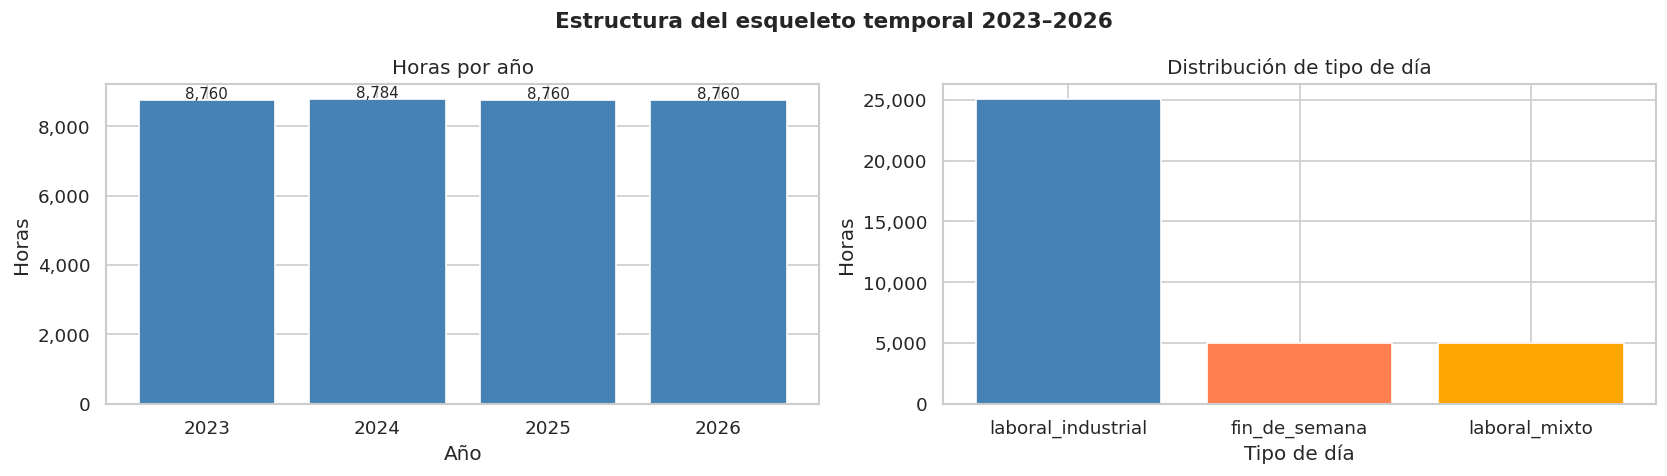

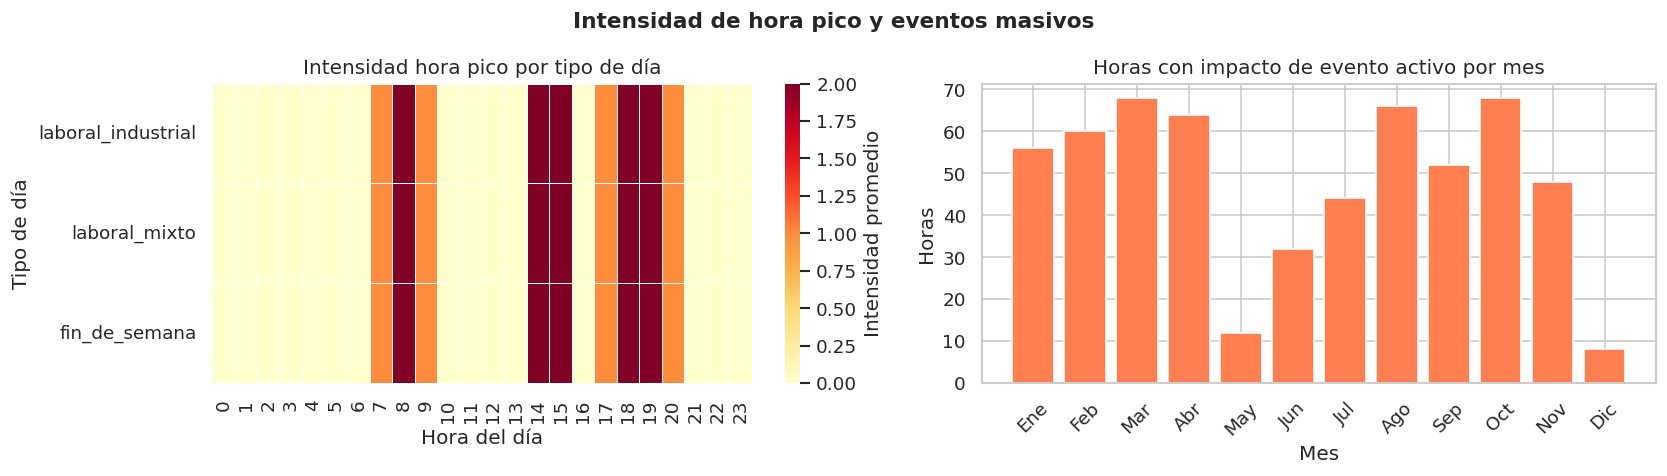

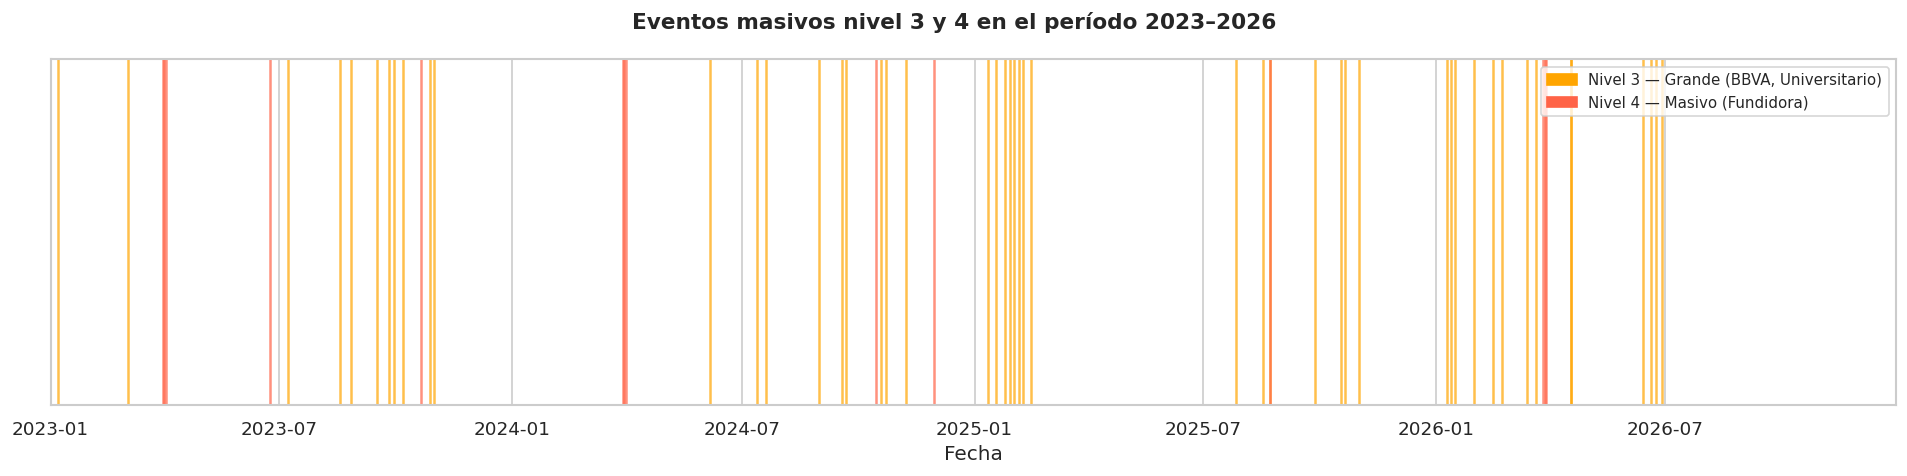

✅ 3 figuras generadas y guardadas


In [13]:
# ============================================================
# CELDA 5 — Visualizaciones del esqueleto temporal
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

df_tiempo['fecha_hora'] = pd.to_datetime(df_tiempo['fecha_hora'])

# ============================================================
# FIGURA 1 — Cobertura del esqueleto y distribución de tipo_dia
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Estructura del esqueleto temporal 2023–2026',
             fontsize=13, fontweight='bold')

# 1A — Horas por año
horas_año = df_tiempo.groupby('año').size()
axes[0].bar(horas_año.index.astype(str), horas_año.values,
            color='steelblue', edgecolor='white')
axes[0].set_title('Horas por año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Horas')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
for i, (año, val) in enumerate(horas_año.items()):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontsize=9)

# 1B — Distribución de tipo_dia
tipo_counts = df_tiempo['tipo_dia'].value_counts()
colores_tipo = {
    'laboral_industrial': 'steelblue',
    'laboral_mixto':      'orange',
    'fin_de_semana':      'coral'
}
colores = [colores_tipo[t] for t in tipo_counts.index]
axes[1].bar(tipo_counts.index, tipo_counts.values,
            color=colores, edgecolor='white')
axes[1].set_title('Distribución de tipo de día')
axes[1].set_xlabel('Tipo de día')
axes[1].set_ylabel('Horas')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('nb02_fig1_estructura_esqueleto.png', bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 2 — Intensidad de hora pico por tipo de día
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Intensidad de hora pico y eventos masivos',
             fontsize=13, fontweight='bold')

# 2A — Heatmap intensidad_hora_pico por hora y tipo_dia
pivot_pico = df_tiempo.groupby(
    ['tipo_dia', 'hora_del_dia'])['intensidad_hora_pico'].mean().unstack()

orden = ['laboral_industrial', 'laboral_mixto', 'fin_de_semana']
pivot_pico = pivot_pico.reindex(orden)

sns.heatmap(pivot_pico, ax=axes[0], cmap='YlOrRd',
            linewidths=0.3, vmin=0, vmax=2,
            cbar_kws={'label': 'Intensidad promedio'})
axes[0].set_title('Intensidad hora pico por tipo de día')
axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('Tipo de día')

# 2B — Eventos masivos por mes (impacto_evento_activo > 0)
df_eventos_activos = df_tiempo[df_tiempo['impacto_evento_activo'] > 0].copy()
eventos_mes = df_eventos_activos.groupby('mes').size()
meses = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']
axes[1].bar([meses[i-1] for i in eventos_mes.index],
            eventos_mes.values, color='coral', edgecolor='white')
axes[1].set_title('Horas con impacto de evento activo por mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Horas')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('nb02_fig2_pico_y_eventos.png', bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 3 — Línea de tiempo de eventos nivel 3 y 4
# ============================================================
fig, ax = plt.subplots(figsize=(16, 4))
fig.suptitle('Eventos masivos nivel 3 y 4 en el período 2023–2026',
             fontsize=13, fontweight='bold')

df_eventos['fecha'] = pd.to_datetime(df_eventos['fecha'])
eventos_altos = df_eventos[df_eventos['nivel_impacto'] >= 3]

colores_nivel = {3: 'orange', 4: 'tomato'}
for _, row in eventos_altos.iterrows():
    ax.axvline(x=row['fecha'],
               color=colores_nivel[row['nivel_impacto']],
               alpha=0.7, linewidth=1.5)

ax.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2026-12-31'))
ax.set_xlabel('Fecha')
ax.set_yticks([])

from matplotlib.patches import Patch
leyenda = [Patch(color='orange', label='Nivel 3 — Grande (BBVA, Universitario)'),
           Patch(color='tomato', label='Nivel 4 — Masivo (Fundidora)')]
ax.legend(handles=leyenda, fontsize=9)

plt.tight_layout()
plt.savefig('nb02_fig3_timeline_eventos.png', bbox_inches='tight')
plt.show()

print("✅ 3 figuras generadas y guardadas")

## Conclusiones — Notebook 02

### Esqueleto temporal
- 35,064 horas: 2023-2026 completo, sin huecos
- 2024 con 8,784h por año bisiesto — correcto
- Tres perfiles de día validados visualmente en heatmap

### Variables construidas
- `intensidad_hora_pico` (0/1/2): captura gradiente real
  de congestión, no solo presencia/ausencia
- `tipo_dia`: tres perfiles distintos confirmados en heatmap
- `impacto_evento_activo`: señal anticipada 3h antes del evento

### Eventos masivos
- 148 eventos 2023-2026, niveles redefinidos por aforo del recinto
- Nivel 4 (Fundidora, >53k) correctamente identificado como categoría única
- Mayor densidad de eventos: julio-octubre (temporada Apertura + festivales)
- Mayo y diciembre: meses con menor impacto de eventos masivos

### Limitaciones documentadas
- `asistencia_estimada` = aforo del recinto, no asistencia real
- Punto único de clima (Macroplaza) para toda la ZMM — ver Notebook 03
- Eventos manuales: pueden existir eventos no registrados de menor relevancia
```